# VECTRA-X
## A Leakage-Aware, Multi-Label, and Uncertainty-Conscious Clinical Triage Study

**FIT Competition 2026 - Track IV: AI-based Vector-Borne Disease Prediction**

This notebook is the canonical scientific submission. It executes from the raw
competition files, applies a frozen-test protocol, and regenerates all evidence
without loading precomputed analytical results.

> **Clinical scope.** VECTRA-X is a research decision-support prototype. It is
> not a diagnostic device, treatment recommendation system, or substitute for
> qualified clinical judgment.

# Executive Abstract

Febrile syndromes caused by malaria, dengue, typhoid fever, yellow fever, and
other conditions overlap clinically and can co-occur. This study therefore
frames the competition data as a stage-aware multi-label problem rather than a
single-class prediction task. The analytical protocol begins with target
integrity and leakage governance, then compares transparent baselines and
regularized models using training-only validation before one frozen-test
evaluation.

The central methodological finding is that a free-text field describing other
diseases is transformed by the original preprocessing logic into a presence
indicator that nearly restates the `other_diseases` target. The corrected
workflow excludes that field from deployable tracks, excludes the single row
whose diagnosis targets are all unknown, reports repeated validation and
uncertainty intervals, separates exact and pragmatic prediction-set policies,
and treats triage outputs as scenario projections.

The executed result tables below provide the final numerical abstract. No
performance value is stated here before computation.

### Contributions

| Conventional competition workflow | VECTRA-X research contribution |
|---|---|
| Single-label assumption | Empirically validated multi-label framing |
| One undifferentiated feature matrix | Pre-lab, lab-aware, and research-only governance |
| Raw-column leakage scan | Screening of actual derived model representations |
| Single validation split | Repeated training-only validation plus a frozen test |
| Point estimates only | Support counts and bootstrap uncertainty intervals |
| Forced predictions | Calibration, prediction sets, and selective-risk analysis |
| Proxy explanation | Explanation of the selected deployed estimator |
| Aggregate fairness gaps | Denominators, TP/FN counts, intervals, and evidence status |
| Operational impact claim | Explicitly assumption-bound scenario projections |

# 1. Reproducibility, Environment, and Provenance

The first executable cell resolves the repository root without assuming the
notebook's launch directory. The workflow fixes deterministic seeds and records
software versions. Mandatory dependencies fail loudly; optional model engines
are not required for the primary conclusions.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "config" / "config.yaml").exists():
    ROOT = ROOT.parent
if not (ROOT / "config" / "config.yaml").exists():
    raise RuntimeError("Could not locate the VECTRA-X project root.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")
print(f"Project root: {ROOT}")

Project root: C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project


In [2]:
import json
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display

from src.notebook_workflow import run_research_workflow

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

versions = pd.DataFrame(
    {
        "component": ["Python", "Platform", "pandas", "NumPy", "scikit-learn"],
        "version": [
            platform.python_version(),
            platform.platform(),
            pd.__version__,
            np.__version__,
            sklearn.__version__,
        ],
    }
)
display(versions)

,component,version
0,Python,3.12.6
1,Platform,Windows-11-10.0.26200-SP0
2,pandas,3.0.2
3,NumPy,2.4.4
4,scikit-learn,1.8.0


**Interpretation.** The environment manifest makes numerical provenance inspectable and supports independent reruns.

**Limitation.** Exact floating-point values may vary slightly across library versions or processor architectures; scientific conclusions must be judged from effect direction, uncertainty, and support rather than the last decimal place.

## 1.1 Execute the complete research workflow

The following cell performs all feature decisions and model selection using the
training pool only. It then evaluates each locked track once on the frozen test.
Full mode uses ten repeated validation seeds and 2,000 bootstrap draws.

In [3]:
result = run_research_workflow(quick=False)
print("Research workflow complete.")
display(pd.DataFrame([result.cohort_audit]))

19:29:48 | INFO    | src.data_loader | Loaded raw CSV with encoding=utf-8 sep=';' -> 300 rows x 109 cols


19:29:49 | INFO    | src.data_loader | Loaded data dictionary: 64 rows x 4 cols


19:29:49 | INFO    | src.schema_audit | Schema audit: 109 cols -> 14 numeric, 81 binary, 1 categorical, 11 constant, 1 high-cardinality; 0 duplicate rows.


19:29:50 | INFO    | src.label_detection | Detected 8 label columns -> 5 ACTIVE ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever'], 3 INACTIVE ['chikungunya', 'zika', 'option_8']


19:29:53 | INFO    | src.leakage_audit | Leakage audit -> PRE_LAB=81, LAB_AWARE=97, FULL=99 features (lab-test=16, research-only=2).


...

19:29:54 | INFO    | src.preprocessing | Dropped constant columns: ['Inflammation de conjonctivite', 'Rougeur faciale (Facial flushing)', 'Sudation excessive (Profuse sweating)', 'Maladie rhumatismale', 'Maladie auto immune', 'Allergies', 'Cancer', 'Carences en leucocytes (Leucopenia)']


C:\Users\rapha\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


19:51:23 | INFO    | src.explainability | TreeSHAP local explanation failed for dengue: Must pass 2-d input. shape=(3, 81, 2)


Research workflow complete.


,n_raw,n_supervised,n_excluded_unknown_target,excluded_indices
0,300,299,1,[158]


In [4]:
executive = result.final_test_metrics[
    ["track", "model", "macro_f1", "macro_pr_auc", "macro_recall", "micro_f1"]
].copy()
display(Markdown("### Executed numerical abstract"))
display(executive.style.format(precision=3))
display(result.safe_claims)

### Executed numerical abstract

,track,model,macro_f1,macro_pr_auc,macro_recall,micro_f1
0,PRE_LAB,extra_trees,0.482,0.525,0.501,0.767
1,LAB_AWARE,hist_gb,0.444,0.502,0.522,0.732


,claim,evidence,status
0,The verified supervised cohort contains 299 pa...,One row with all diagnosis targets missing was...,supported
1,The dataset is multi-label and severely imbala...,158 patients have multiple active labels.,supported
2,The other-disease presentation field is a targ...,Presence-indicator AUC is documented in the re...,supported
3,Laboratory-aware modeling improves frozen-test...,PRE_LAB=0.482; LAB_AWARE=0.444.,not supported
4,Prediction-set evidence is exact only for the ...,Exact and pragmatic modes are reported separat...,supported


**Interpretation.** The numerical abstract is generated only after the complete protocol has executed; this prevents stale headline metrics from surviving a methodological correction.

**Limitation.** The frozen test is small. Its values are final descriptive estimates for this dataset, not population-level guarantees.

# 2. Data Integrity and Target Audit

## Research Question 1

**Can every row be treated as a fully labeled supervised observation?**

The original target conversion mapped missing diagnosis cells to zero. That
operation confounded an unknown diagnosis with a confirmed negative diagnosis.
The corrected workflow preserves nullable targets and excludes rows lacking a
complete diagnosis vector from supervised modeling.

In [5]:
cohort_table = pd.DataFrame([result.cohort_audit])
display(cohort_table)
display(result.target_distribution)
display(result.label_text_validation)

,n_raw,n_supervised,n_excluded_unknown_target,excluded_indices
0,300,299,1,[158]


,label,positives,prevalence_pct,status
0,malaria,270,90.30,active
1,other_diseases,99,33.11,active
2,dengue,56,18.73,active
3,typhoid,29,9.70,active
4,yellow_fever,12,4.01,active
5,chikungunya,0,0.00,inactive
6,zika,0,0.00,inactive
7,option_8,0,0.00,inactive


,label,binary_positives,text_positives,agreement_rows,agreement_pct
0,malaria,270,270,299,100.0
1,dengue,56,56,299,100.0
2,chikungunya,0,0,299,100.0
3,yellow_fever,12,12,299,100.0
4,typhoid,29,29,299,100.0
5,zika,0,0,299,100.0
6,other_diseases,99,99,299,100.0
7,option_8,0,0,299,100.0


**Interpretation.** One raw observation has no recorded diagnosis targets and is excluded, yielding a verified supervised cohort of 299 patients. Target prevalence is therefore computed on confirmed supervised observations only.

**Limitation.** Exclusion is methodologically preferable to inventing negative labels, but the underlying diagnosis cannot be recovered without the source data custodian.

## 2.1 Multi-label structure and imbalance

The target vector is not mutually exclusive. Cardinality and co-occurrence are
examined before choosing the learning formulation. Macro-averaged metrics and
per-label recall are emphasized because malaria prevalence can dominate micro
metrics and subset accuracy.

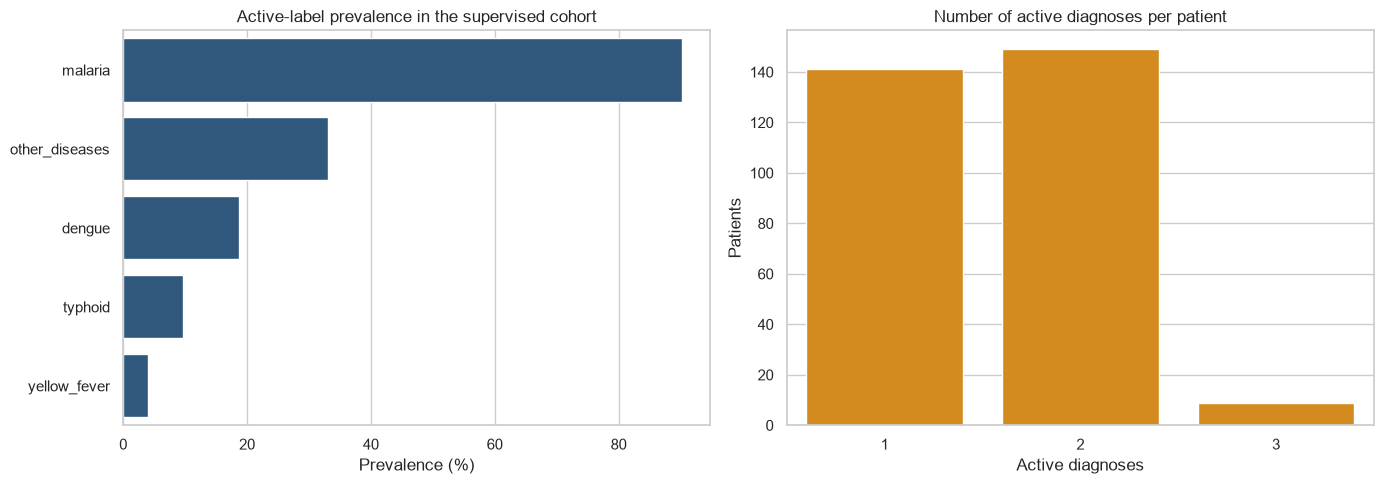

,combination,n_patients
0,malaria,119
1,malaria+other_diseases,74
2,malaria+dengue,36
3,malaria+typhoid,24
4,other_diseases,14
5,malaria+yellow_fever,8
6,dengue,8
7,malaria+other_diseases+dengue,5
8,other_diseases+dengue,3
9,dengue+yellow_fever,2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dist = result.target_distribution[result.target_distribution["status"] == "active"]
sns.barplot(data=dist, x="prevalence_pct", y="label", ax=axes[0], color="#235789")
axes[0].set_title("Active-label prevalence in the supervised cohort")
axes[0].set_xlabel("Prevalence (%)")
axes[0].set_ylabel("")

card = result.target_cardinality
sns.barplot(data=card, x="n_labels", y="n_patients", ax=axes[1], color="#F18F01")
axes[1].set_title("Number of active diagnoses per patient")
axes[1].set_xlabel("Active diagnoses")
axes[1].set_ylabel("Patients")
plt.tight_layout()
plt.show()
display(result.top_combinations.head(12))

**Interpretation.** Multiple diagnoses occur frequently enough that collapsing the outcome to one class would discard clinically and statistically material information. Severe imbalance makes always-malaria a necessary reference baseline.

**Limitation.** Co-occurrence describes the observed cohort and must not be interpreted as causal interaction between diseases.

# 3. Exploratory Analysis and Missingness

Missingness is analyzed as both a data-quality concern and a possible workflow
signal. It is not automatically interpreted as biological evidence. The table
below identifies the most incomplete variables before preprocessing.

,column,n_missing,missing_pct,role
0,Circonference du bras (Mua circumference),275,91.67,numeric
1,Temps de remplissage capillaire (médiane secs ...,209,69.67,numeric
2,Autres maladies présentées par le patient,206,68.67,text_high_cardinality
3,Pression artérielle (moyenne mmHg ± SD). / Art...,171,57.00,numeric
4,Lymphocytes,153,51.00,numeric
5,Hematocrite (Hematrocrit),105,35.00,numeric
6,Poids (Weight),104,34.67,numeric
7,Fréquence respiratoire (médiane IQR) / Respira...,88,29.33,numeric
8,Créatinine élevée / Elevated Creatinine,82,27.33,numeric
9,Neutrophiles / Neutrophils,81,27.00,numeric


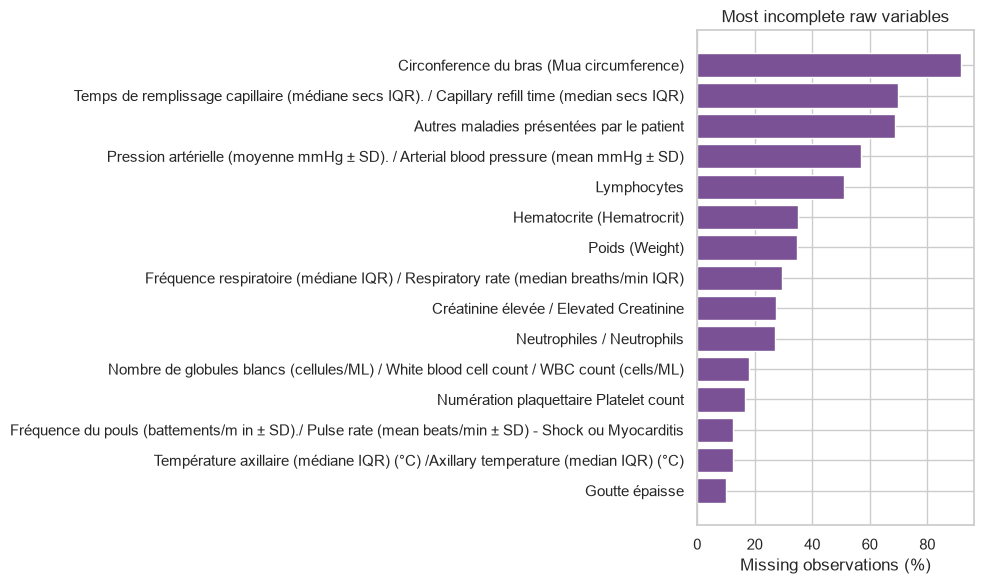

In [7]:
display(result.missingness_table.head(20))
top_missing = result.missingness_table.head(15).sort_values("missing_pct")
plt.figure(figsize=(10, 6))
plt.barh(top_missing["column"], top_missing["missing_pct"], color="#7A5195")
plt.xlabel("Missing observations (%)")
plt.title("Most incomplete raw variables")
plt.tight_layout()
plt.show()

**Interpretation.** Missingness is substantial in several vital and laboratory variables, supporting fold-local imputation and explicit missingness indicators where justified.

**Limitation.** A missingness indicator may encode clinical workflow or site behavior. Its predictive value does not establish physiological relevance and is separately ablated.

# 4. Leakage Discovery and Clinical-Stage Governance

## Research Question 2

**Do any pre-lab features restate the target after transformation?**

Leakage is screened at the representation consumed by the model. For each raw
feature the audit evaluates model encoding, missingness, and high-cardinality
presence indicators. Bilingual semantic aliases and explicit clinical-stage
rules supplement the statistical screen.

In [8]:
leak_cols = [
    "feature", "derived_representation", "best_label",
    "max_single_feature_auc", "mutual_info", "stage", "decision", "rationale"
]
display(result.leakage_candidates[leak_cols].head(25))

,feature,derived_representation,best_label,max_single_feature_auc,mutual_info,stage,decision,rationale
0,Dengue (Dengua),model_encoding,dengue,0.9762,0.4423,T3_restate,research_only,Disease-named feature ~ target (post-diagnosis)
1,Autres maladies présentées par le patient,presence,other_diseases,0.9662,0.5321,T3_restate,research_only,Explicitly governed target-restatement / post-...
2,Test TDR,model_encoding,malaria,0.8279,0.0585,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
3,Goutte épaisse,model_encoding,malaria,0.7901,0.0549,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
4,Neutrophiles / Neutrophils,model_encoding,typhoid,0.7119,0.0932,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
5,Nombre de globules blancs (cellules/ML) / Whit...,missing_indicator,yellow_fever,0.6834,0.0063,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
6,Hematocrite (Hematrocrit),model_encoding,malaria,0.6802,0.0284,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
7,Lymphocytes,missing_indicator,typhoid,0.6679,0.0241,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
8,Numération plaquettaire Platelet count,model_encoding,other_diseases,0.6454,0.0485,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
9,Hémoconcentration,model_encoding,typhoid,0.6280,0.0020,T2_lab,lab_aware,Ordered lab / rapid diagnostic test


**Interpretation.** The audit identifies both known diagnostic restatements and the other-disease presentation field. The latter is dangerous because its presence, not its text content, almost duplicates the target.

**Limitation.** A high univariate AUC is a warning signal rather than proof of leakage by itself; final governance combines temporal availability, semantics, data provenance, and statistics.

## 4.1 The other-disease restatement case

The free-text field `Autres maladies présentées par le patient` is populated
almost exclusively when the `other_diseases` target is positive. The former
pipeline discarded the text but retained whether text was present. The old
ordinal screen and the actual model representation were therefore different.

In [9]:
other_case = result.leakage_audit[
    result.leakage_audit["feature"].str.contains("Autres maladies", case=False, na=False)
][leak_cols]
display(other_case)

stage_summary = (
    result.leakage_audit.groupby(["decision", "stage"])
    .size().rename("n_raw_features").reset_index()
)
display(stage_summary)

,feature,derived_representation,best_label,max_single_feature_auc,mutual_info,stage,decision,rationale
98,Autres maladies présentées par le patient,presence,other_diseases,0.9662,0.5321,T3_restate,research_only,Explicitly governed target-restatement / post-...


,decision,stage,n_raw_features
0,lab_aware,T2_lab,16
1,pre_lab,T0_intake,76
2,pre_lab,T1_vital,5
3,research_only,T3_restate,2


**Interpretation.** The corrected audit evaluates the presence indicator directly and routes the field to research-only status. It cannot enter either deployable design frame.

**Limitation.** Removing a target restatement reduces apparent performance. That reduction is evidence of improved validity, not model deterioration.

## 4.2 Feature contract and assertions

Every transformed feature retains its raw-source provenance and stage decision.
The workflow raises an exception if a deployable matrix contains any derived
column sourced from a research-only field.

In [10]:
display(
    result.feature_contract.groupby(["track", "decision"])
    .size().rename("n_model_features").reset_index()
)
display(result.feature_contract.head(20))

,track,decision,n_model_features
0,LAB_AWARE,lab_aware,24
1,LAB_AWARE,pre_lab,81
2,PRE_LAB,pre_lab,81
3,RESEARCH_FULL,lab_aware,24
4,RESEARCH_FULL,pre_lab,81
5,RESEARCH_FULL,research_only,2


,track,raw_feature,model_feature,stage,decision
0,PRE_LAB,Centre de santé,center_code,T0_intake,pre_lab
1,PRE_LAB,Genre (Gender),gender_female,T0_intake,pre_lab
2,PRE_LAB,Âge (Age),Âge (Age),T0_intake,pre_lab
3,PRE_LAB,Poids (Weight),Poids (Weight),T0_intake,pre_lab
4,PRE_LAB,Poids (Weight),Poids (Weight)__missing,T0_intake,pre_lab
5,PRE_LAB,Circonference du bras (Mua circumference),Circonference du bras (Mua circumference),T0_intake,pre_lab
6,PRE_LAB,"Haute température.(temperature, Hyperpyrexia)","Haute température.(temperature, Hyperpyrexia)",T0_intake,pre_lab
7,PRE_LAB,Fièvre depuis 48 heures(Fever 48 hrs),Fièvre depuis 48 heures(Fever 48 hrs),T0_intake,pre_lab
8,PRE_LAB,Fièvre au cours des 7 derniers jours (Fever in...,Fièvre au cours des 7 derniers jours (Fever in...,T0_intake,pre_lab
9,PRE_LAB,Type de fièvre (Type of Fever),Type de fièvre (Type of Fever),T0_intake,pre_lab


**Interpretation.** Provenance-aware assertions close the gap between a raw-column audit and the transformed matrix used for learning.

**Limitation.** Clinical availability stages are derived from the available dictionary and field semantics; prospective deployment would require direct workflow timestamps.

# 5. Leakage-Safe Preprocessing

The preprocessing contract includes decimal-comma parsing, binary token
normalization, blood-pressure decomposition, categorical encoding, and
missingness indicators. Stateful imputation and scaling are fitted inside each
training fold. The test set is transformed only by objects fitted on training
data.

In [11]:
frame_summary = pd.DataFrame(
    [
        {
            "track": name,
            "patients": frame.shape[0],
            "model_features": frame.shape[1],
            "missing_cells": int(frame.isna().sum().sum()),
        }
        for name, frame in result.design_frames.items()
    ]
)
display(frame_summary)

,track,patients,model_features,missing_cells
0,PRE_LAB,299,81,1157
1,LAB_AWARE,299,105,1814
2,RESEARCH_FULL,299,107,1820


**Interpretation.** The stage-gated matrices differ by information availability, permitting an honest comparison between early triage and post-test confirmation.

**Limitation.** Factorized low-cardinality categories impose an artificial ordering. The principal conclusions therefore rely on robust comparisons and should be re-evaluated with one-hot or target-safe categorical handling in a larger cohort.

# 6. Experimental Protocol

## Frozen-test discipline

1. A deterministic multi-label-stratified split creates a training pool and a
   frozen test.
2. Leakage statistics, feature decisions, model selection, thresholds, and
   calibration are learned using training data only.
3. Candidate models are compared with out-of-fold predictions.
4. The selected model is re-evaluated across ten deterministic validation seeds.
5. Each locked track is evaluated once on the frozen test.

The primary selection metric is macro PR-AUC because it respects label imbalance
and evaluates ranking without committing to a single threshold.

In [12]:
display(result.split_support.pivot(index="label", columns="partition", values="positives"))
display(result.selection_audit)
display(result.final_test_audit)

partition,frozen_test,train
label,,
dengue,14,42
malaria,68,202
other_diseases,25,74
typhoid,7,22
yellow_fever,3,9


,track,selected_model,criterion,data_partition
0,PRE_LAB,extra_trees,training OOF macro-PR-AUC,training_only
1,LAB_AWARE,hist_gb,training OOF macro-PR-AUC,training_only


,track,evaluations_per_track,selection_used_test
0,PRE_LAB,1,False
1,LAB_AWARE,1,False


**Interpretation.** The audit tables show that the frozen test is absent from feature and model selection and is evaluated once per locked track.

**Limitation.** Even a correctly isolated test of approximately one quarter of 299 patients contains very few positives for rare labels; one error can materially change recall.

# 7. Baselines and Ablation Studies

## Research Question 3

**How much value is added beyond prevalence-driven rules, and which feature
families are responsible?**

Always-malaria, prevalence, and prevalence-matched random baselines establish a
minimum reference. Ablations remove center identity and missingness indicators
under the same training-only protocol.

In [13]:
display(result.baselines.style.format(precision=3))
display(result.ablations.style.format(precision=3))

,baseline,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision
0,always_malaria,0.697,0.186,0.541,0.720,0.151,0.423,0.645,0.200,0.174
1,prevalence,0.697,0.186,0.541,0.720,0.151,0.423,0.645,0.200,0.174
2,random_prevalence,0.658,0.312,0.639,0.672,0.205,0.295,0.576,0.317,0.309


,ablation,n_features,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc
0,all_pre_lab,81,0.785,0.553,0.787,0.788,0.139,0.507,0.719,0.570,0.543,0.709,0.504
1,without_center,80,0.782,0.550,0.785,0.786,0.142,0.507,0.716,0.575,0.533,0.703,0.495
2,without_missing_indicators,76,0.777,0.550,0.786,0.782,0.147,0.484,0.709,0.591,0.524,0.732,0.529


**Interpretation.** Baselines reveal whether a sophisticated model improves macro-level discrimination rather than merely reproducing malaria prevalence. Ablations quantify the marginal contribution of center and missingness signals.

**Limitation.** Ablation effects are conditional on the selected estimator and available sample. Small differences should not be treated as definitive feature utility.

# 8. Model Development and Repeated Validation

Candidate estimators are deliberately regularized and limited to defensible
tabular methods. A modest inner-CV grid compares Logistic Regression
regularization (`C=0.1, 0.5, 2.0`) and Extra Trees leaf sizes (`2, 5`) alongside
Random Forest and HistGradientBoosting. Model breadth is secondary to validation
quality. The table below reports training-only out-of-fold comparison; the
repeated analysis then shows seed sensitivity for the selected estimator.

In [14]:
comparison = result.model_comparison.sort_values(
    ["track", "macro_pr_auc"], ascending=[True, False]
)
display(comparison.style.format(precision=3))

repeated_summary = (
    result.repeated_validation.groupby("track")
    .agg(
        seeds=("seed", "nunique"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        macro_pr_auc_mean=("macro_pr_auc", "mean"),
        macro_pr_auc_sd=("macro_pr_auc", "std"),
    )
    .reset_index()
)
display(repeated_summary.style.format(precision=3))

,track,model,data_partition,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc
13,LAB_AWARE,hist_gb,training_only,0.778,0.466,0.753,0.781,0.132,0.502,0.710,0.419,0.582,0.771,0.535
11,LAB_AWARE,extra_trees,training_only,0.799,0.503,0.791,0.812,0.127,0.547,0.746,0.502,0.506,0.757,0.527
10,LAB_AWARE,random_forest,training_only,0.791,0.465,0.757,0.804,0.125,0.529,0.734,0.421,0.562,0.759,0.523
12,LAB_AWARE,extra_trees_leaf5,training_only,0.749,0.520,0.772,0.765,0.167,0.439,0.686,0.578,0.490,0.760,0.509
7,LAB_AWARE,logreg_c0.1,training_only,0.673,0.482,0.741,0.688,0.234,0.317,0.591,0.603,0.445,0.732,0.468
8,LAB_AWARE,logreg,training_only,0.707,0.481,0.756,0.713,0.201,0.353,0.623,0.543,0.454,0.731,0.464
9,LAB_AWARE,logreg_c2.0,training_only,0.726,0.485,0.761,0.726,0.185,0.366,0.638,0.533,0.457,0.708,0.449
4,PRE_LAB,extra_trees,training_only,0.785,0.553,0.787,0.788,0.139,0.507,0.719,0.570,0.543,0.709,0.504
5,PRE_LAB,extra_trees_leaf5,training_only,0.740,0.522,0.767,0.746,0.176,0.448,0.672,0.599,0.484,0.705,0.493
3,PRE_LAB,random_forest,training_only,0.781,0.440,0.750,0.794,0.133,0.516,0.723,0.412,0.494,0.714,0.486


,track,seeds,macro_f1_mean,macro_f1_sd,macro_pr_auc_mean,macro_pr_auc_sd
0,LAB_AWARE,10,0.437,0.022,0.499,0.020
1,PRE_LAB,10,0.533,0.020,0.509,0.011


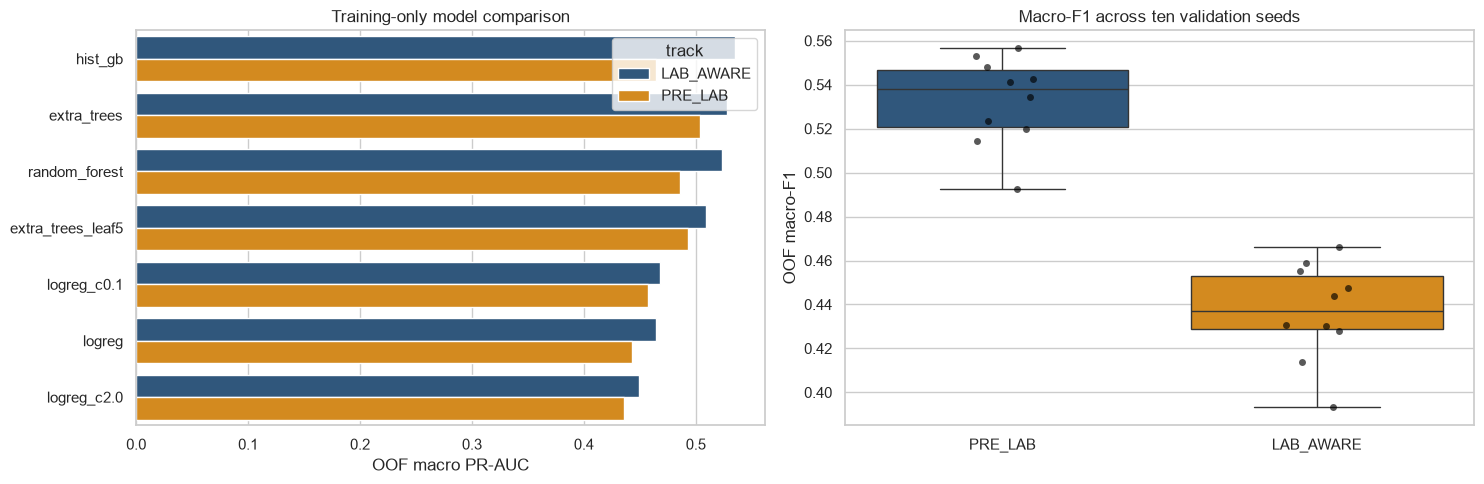

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=comparison, x="macro_pr_auc", y="model", hue="track",
    ax=axes[0], palette=["#235789", "#F18F01"]
)
axes[0].set_title("Training-only model comparison")
axes[0].set_xlabel("OOF macro PR-AUC")
axes[0].set_ylabel("")

sns.boxplot(
    data=result.repeated_validation, x="track", y="macro_f1",
    ax=axes[1], palette=["#235789", "#F18F01"]
)
sns.stripplot(
    data=result.repeated_validation, x="track", y="macro_f1",
    ax=axes[1], color="black", alpha=0.65
)
axes[1].set_title("Macro-F1 across ten validation seeds")
axes[1].set_xlabel("")
axes[1].set_ylabel("OOF macro-F1")
plt.tight_layout()
plt.show()

**Interpretation.** Repeated validation exposes the variability hidden by a single split and provides the appropriate evidence for model selection.

**Limitation.** Repeated folds are not independent new cohorts. Their dispersion measures resampling sensitivity, not external clinical generalizability.

# 9. Final Frozen-Test Evaluation

## Research Question 4

**After leakage removal and policy locking, how well do pre-lab and lab-aware
models generalize to the untouched test patients?**

In [16]:
display(result.final_test_metrics.style.format(precision=3))
display(
    result.final_per_label[
        ["track", "label", "support_pos", "precision", "recall", "f1",
         "pr_auc", "tp", "fp", "fn", "tn"]
    ].style.format(precision=3)
)

,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc,track,model
0,0.767,0.482,0.755,0.781,0.146,0.449,0.698,0.501,0.468,0.767,0.525,PRE_LAB,extra_trees
1,0.732,0.444,0.750,0.759,0.182,0.346,0.656,0.522,0.402,0.787,0.502,LAB_AWARE,hist_gb


,track,label,support_pos,precision,recall,f1,pr_auc,tp,fp,fn,tn
0,PRE_LAB,malaria,68,0.872,1.000,0.931,0.942,68,10,0,0
1,PRE_LAB,other_diseases,25,0.621,0.720,0.667,0.705,18,11,7,42
2,PRE_LAB,dengue,14,0.417,0.357,0.385,0.507,5,7,9,57
3,PRE_LAB,typhoid,7,0.429,0.429,0.429,0.368,3,4,4,67
4,PRE_LAB,yellow_fever,3,0.000,0.000,0.000,0.101,0,2,3,73
5,LAB_AWARE,malaria,68,0.872,1.000,0.931,0.995,68,10,0,0
6,LAB_AWARE,other_diseases,25,0.654,0.680,0.667,0.707,17,9,8,44
7,LAB_AWARE,dengue,14,0.344,0.786,0.478,0.537,11,21,3,43
8,LAB_AWARE,typhoid,7,0.143,0.143,0.143,0.186,1,6,6,65
9,LAB_AWARE,yellow_fever,3,0.000,0.000,0.000,0.087,0,5,3,70


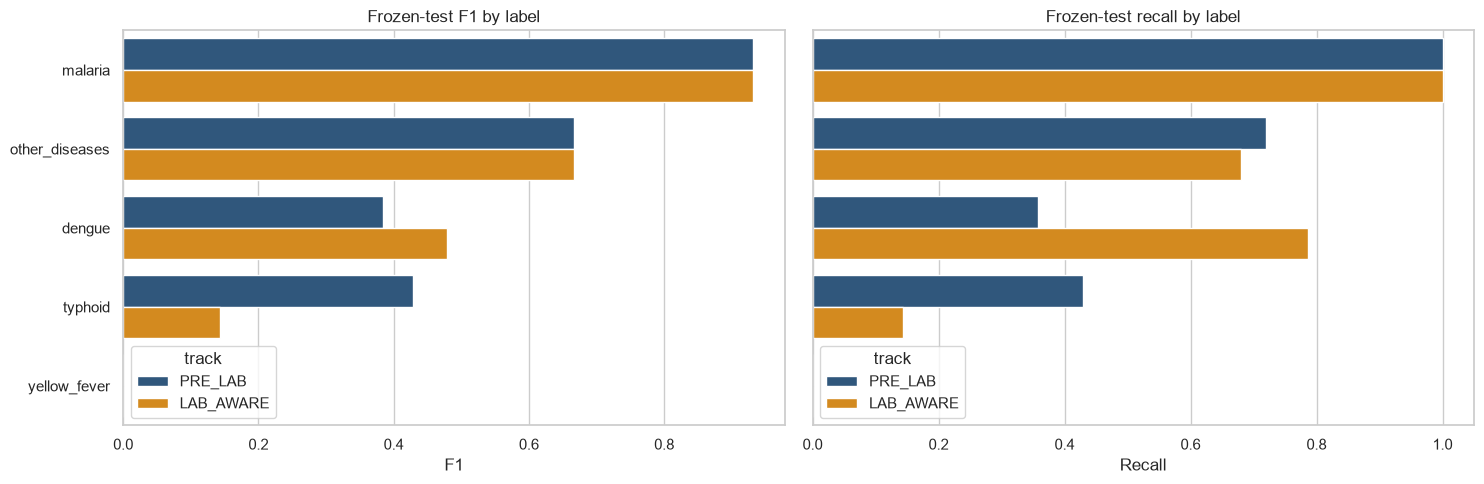

In [17]:
per_label_plot = result.final_per_label.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.barplot(
    data=per_label_plot, x="f1", y="label", hue="track",
    ax=axes[0], palette=["#235789", "#F18F01"]
)
axes[0].set_title("Frozen-test F1 by label")
axes[0].set_xlabel("F1")
axes[0].set_ylabel("")
sns.barplot(
    data=per_label_plot, x="recall", y="label", hue="track",
    ax=axes[1], palette=["#235789", "#F18F01"]
)
axes[1].set_title("Frozen-test recall by label")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretation.** The frozen-test table is the only source of final performance claims. LAB_AWARE is interpreted as a negative result whenever its paired evidence does not improve on PRE_LAB.

**Limitation.** Rare-label estimates have wide uncertainty because test support is small. Rankings among rare labels are not stable enough for strong clinical conclusions.

## 9.1 Bootstrap intervals and paired track comparison

Intervals are resampled at the patient level. The paired comparison uses the
same test patients for both tracks and reports LAB_AWARE minus PRE_LAB.

In [18]:
display(result.final_intervals.style.format(precision=3))
display(result.paired_track_comparison.style.format(precision=3))

,track,label,metric,estimate,lower,upper,n,support_pos,valid_draws
0,PRE_LAB,malaria,f1,0.932,0.886,0.967,78,68,2000
1,PRE_LAB,malaria,recall,1.000,1.000,1.000,78,68,2000
2,PRE_LAB,malaria,pr_auc,0.942,0.890,0.981,78,68,2000
3,PRE_LAB,other_diseases,f1,0.667,0.510,0.792,78,25,2000
4,PRE_LAB,other_diseases,recall,0.720,0.538,0.885,78,25,2000
5,PRE_LAB,other_diseases,pr_auc,0.705,0.534,0.856,78,25,2000
6,PRE_LAB,dengue,f1,0.385,0.117,0.600,78,14,2000
7,PRE_LAB,dengue,recall,0.357,0.111,0.615,78,14,2000
8,PRE_LAB,dengue,pr_auc,0.507,0.281,0.742,78,14,2000
9,PRE_LAB,typhoid,f1,0.429,0.000,0.727,78,7,2000


,label,metric,estimate,lower,upper,valid_draws
0,malaria,f1,0.000,0.000,0.000,2000
1,other_diseases,f1,0.000,-0.093,0.092,2000
2,dengue,f1,0.094,-0.131,0.331,2000
3,typhoid,f1,-0.286,-0.714,0.222,2000
4,yellow_fever,f1,0.000,0.000,0.000,2000


**Interpretation.** Confidence intervals make the low precision of rare-label estimates visible. A paired interval spanning zero does not support a claim that laboratory features improve the corresponding metric.

**Limitation.** Bootstrap intervals on a small fixed test approximate sampling uncertainty but cannot repair selection bias, label error, or center shift.

# 10. Co-Infection as an Auxiliary Endpoint

Co-infection is defined as more than one active diagnosis. Candidate selection
uses training-only out-of-fold predictions; the selected auxiliary model is then
evaluated once on the frozen test.

In [19]:
display(result.coinfection_results.style.format(precision=3))

,model,partition,roc_auc,pr_auc,recall,specificity,f1
0,logreg_c0.1,training_only_OOF,0.826,0.856,nan,nan,nan
1,logreg,training_only_OOF,0.821,0.854,nan,nan,nan
2,logreg_c2.0,training_only_OOF,0.817,0.848,nan,nan,nan
3,random_forest,training_only_OOF,0.805,0.803,nan,nan,nan
4,extra_trees,training_only_OOF,0.812,0.821,nan,nan,nan
5,extra_trees_leaf5,training_only_OOF,0.803,0.822,nan,nan,nan
6,hist_gb,training_only_OOF,0.761,0.770,nan,nan,nan
7,logreg_c0.1,frozen_test_once,0.665,0.696,0.605,0.775,0.657


**Interpretation.** Independent frozen-test evaluation removes the optimistic practice of selecting and reporting a co-infection model on the same OOF predictions.

**Limitation.** The target is derived from the diagnosis vector and is not a separately adjudicated clinical endpoint.

# 11. Calibration and Prediction Sets

## 11.1 Cross-fitted probability calibration

Each training patient receives a calibrated OOF probability from a calibrator
that did not observe that patient's label. Test probabilities are calibrated
using training OOF predictions only.

In [20]:
display(result.calibration_metrics.style.format(precision=3))
display(result.calibration_audit.head())

,label,base_rate,brier,ece,mean_pred,variant
0,malaria,0.872,0.113,0.080,0.857,uncalibrated
1,other_diseases,0.321,0.150,0.150,0.338,uncalibrated
2,dengue,0.179,0.128,0.105,0.258,uncalibrated
3,typhoid,0.090,0.090,0.097,0.175,uncalibrated
4,yellow_fever,0.038,0.051,0.055,0.093,uncalibrated
5,malaria,0.872,0.114,0.056,0.926,calibrated_from_training_OOF
6,other_diseases,0.321,0.171,0.160,0.279,calibrated_from_training_OOF
7,dengue,0.179,0.130,0.057,0.167,calibrated_from_training_OOF
8,typhoid,0.090,0.072,0.080,0.090,calibrated_from_training_OOF
9,yellow_fever,0.038,0.037,0.000,0.038,calibrated_from_training_OOF


,target_index,label,fold,calibration_indices,n_calibration,support_pos
0,9,malaria,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",176,161
1,15,malaria,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",176,161
2,16,malaria,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",176,161
3,18,malaria,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",176,161
4,25,malaria,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...",176,161


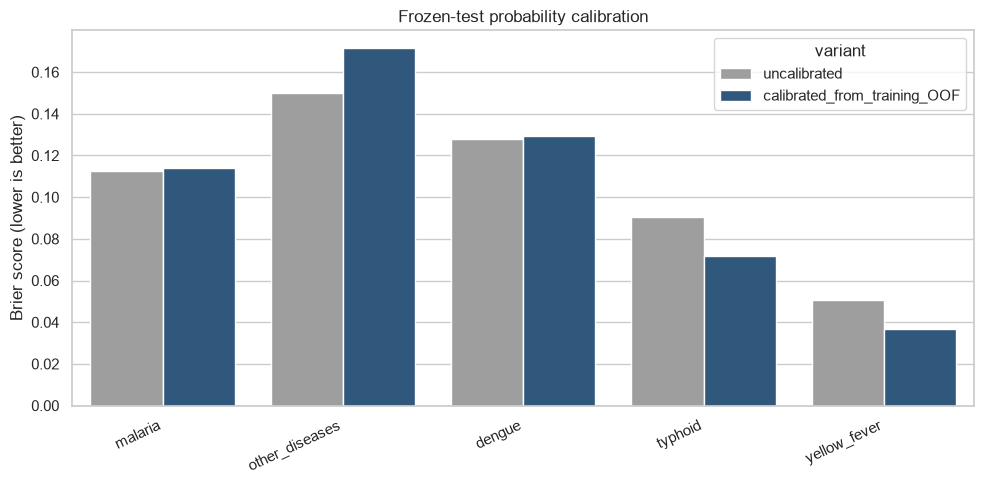

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=result.calibration_metrics,
    x="label", y="brier", hue="variant",
    palette=["#9E9E9E", "#235789"]
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Brier score (lower is better)")
plt.xlabel("")
plt.title("Frozen-test probability calibration")
plt.tight_layout()
plt.show()

**Interpretation.** Cross-fitting removes the in-sample calibration-layer optimism present in the former cohort dashboard workflow.

**Limitation.** Calibration remains difficult for labels with few positives; ECE is bin-dependent and should be read alongside Brier score, prevalence, and reliability plots.

## 11.2 Exact and pragmatic label-wise inclusion sets

The **exact empirical policy** uses the uncapped finite-sample corrected
quantile. The **pragmatic policy** caps the quantile for efficiency and is
reported separately. The pragmatic policy carries no formal coverage claim.

In [22]:
display(Markdown("#### Exact uncapped empirical policy"))
display(result.conformal_exact)
display(pd.DataFrame([result.conformal_exact_summary]))

display(Markdown("#### Pragmatic efficiency policy"))
display(result.conformal_pragmatic)
display(pd.DataFrame([result.conformal_pragmatic_summary]))

#### Exact uncapped empirical policy

,label,prob_threshold,test_positives,covered_positives,empirical_coverage,predicted_inclusions
0,malaria,0.8421,68,68,1.0000,78
1,other_diseases,0.0930,25,25,1.0000,68
2,dengue,0.0741,14,13,0.9286,48
3,typhoid,0.0252,7,7,1.0000,78
4,yellow_fever,0.0247,3,3,1.0000,78


,avg_set_size,pct_empty_sets,pct_singletons,pct_ambiguous_multi,overall_coverage,macro_label_coverage,false_negative_risk
0,4.4872,0.0,0.0,100.0,0.9915,0.9857,0.0085


#### Pragmatic efficiency policy

,label,prob_threshold,test_positives,covered_positives,empirical_coverage,predicted_inclusions
0,malaria,0.8421,68,68,1.0000,78
1,other_diseases,0.2180,25,24,0.9600,42
2,dengue,0.0769,14,13,0.9286,48
3,typhoid,0.0319,7,7,1.0000,63
4,yellow_fever,0.0247,3,3,1.0000,78


,avg_set_size,pct_empty_sets,pct_singletons,pct_ambiguous_multi,overall_coverage,macro_label_coverage,false_negative_risk
0,3.9615,0.0,0.0,100.0,0.9829,0.9777,0.0171


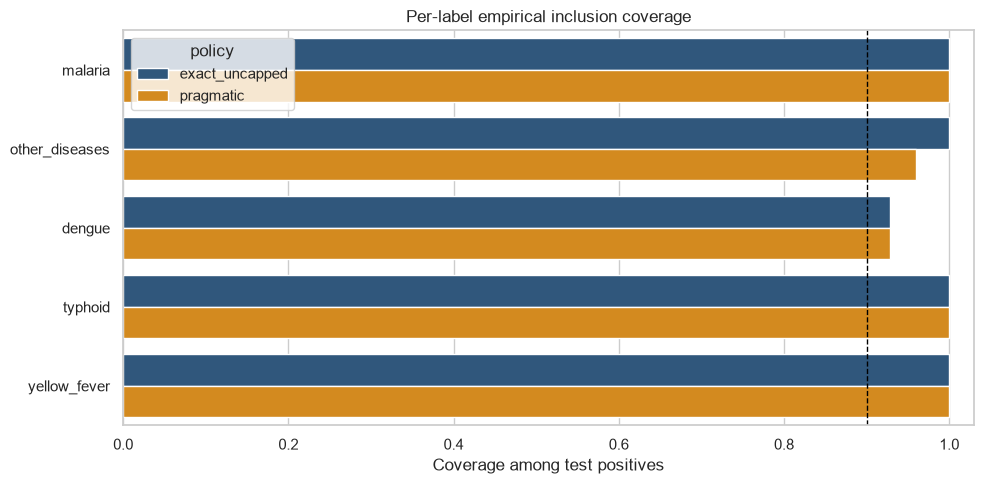

In [23]:
coverage_plot = pd.concat(
    [
        result.conformal_exact.assign(policy="exact_uncapped"),
        result.conformal_pragmatic.assign(policy="pragmatic"),
    ],
    ignore_index=True,
)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=coverage_plot, x="empirical_coverage", y="label", hue="policy",
    palette=["#235789", "#F18F01"]
)
plt.axvline(0.90, color="black", linestyle="--", linewidth=1, label="nominal 0.90")
plt.xlim(0, 1.03)
plt.title("Per-label empirical inclusion coverage")
plt.xlabel("Coverage among test positives")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interpretation.** Separating the policies prevents an efficiency modification from being presented as a formal 90% guarantee. Per-label support and coverage reveal undercoverage hidden by micro averages.

**Limitation.** The label-wise positive-only construction and OOF calibration are an empirical inclusion-set method, not a prospective guarantee under distribution shift.

# 12. Selective Prediction and Uncertainty

## Research Question 5

**Does deferring the most uncertain cases reduce observed error?**

The risk-coverage curve orders test patients by calibrated predictive entropy.
At each retained coverage it reports the subset error rate. This directly tests
whether uncertainty is operationally informative.

,coverage,retained,risk,uncertainty_cutoff
0,1.000000,78,0.551282,0.6262
1,0.987179,77,0.545455,0.6244
2,0.974359,76,0.539474,0.6007
3,0.961538,75,0.533333,0.5949
4,0.948718,74,0.527027,0.5942
5,0.935897,73,0.534247,0.5901
6,0.923077,72,0.527778,0.5842
7,0.910256,71,0.521127,0.5822
8,0.897436,70,0.528571,0.5725
9,0.884615,69,0.521739,0.5678


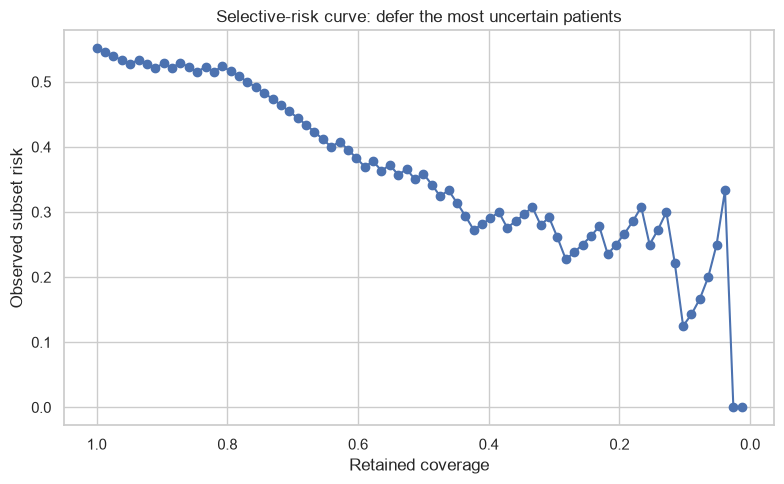

In [24]:
display(result.selective_risk.head(12))
plt.figure(figsize=(8, 5))
plt.plot(result.selective_risk["coverage"], result.selective_risk["risk"], marker="o")
plt.xlabel("Retained coverage")
plt.ylabel("Observed subset risk")
plt.title("Selective-risk curve: defer the most uncertain patients")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

**Interpretation.** A downward risk trend as coverage decreases supports uncertainty-guided deferral. If the curve is flat or irregular, categorical uncertainty tiers should not be claimed as validated.

**Limitation.** Selective risk is evaluated retrospectively on a small test set and does not quantify the clinical cost of deferral.

# 13. Explainability of the Selected Model

Global permutation importance is measured against held-out labels. Local
explanations target the selected deployed estimator: TreeSHAP is used when
supported, with a model-output perturbation fallback otherwise. Alternate
logistic classifiers are not described as surrogates.

In [25]:
display(result.global_importance.head(20))
local = result.local_explanation
display(pd.DataFrame(
    [{"method": local["method"], "label": local["label"], "fidelity": local["fidelity"]}]
))
display(local["contributions"].head())

,feature,importance_mean
0,Poids (Weight)__missing,0.014030
1,Céphalée (Headache),0.013134
2,Diabète,0.012510
3,Détresse respiratoire (Respiratory distress),0.012134
4,Pâleur cutanéo muqueuse ou Anémie (Mucosal ski...,0.012132
5,center_code,0.008432
6,Fréquence du pouls (battements/m in ± SD)./ Pu...,0.008164
7,Douleur abdominale (stomac pain),0.007864
8,Hypertension artérielle,0.007798
9,Type de fièvre (Type of Fever),0.006086


,method,label,fidelity
0,local permutation attribution,dengue,perturbation-based approximation of deployed p...


,center_code,gender_female,Âge (Age),Poids (Weight),Poids (Weight)__missing,Circonference du bras (Mua circumference),"Haute température.(temperature, Hyperpyrexia)",Fièvre depuis 48 heures(Fever 48 hrs),Fièvre au cours des 7 derniers jours (Fever in the last 7 days),Type de fièvre (Type of Fever),Perte de poids (Loss of Weight),Maux de tête (headache),Nausée (Nausea),Vomissement (Vomiting),Douleur articulaire (Joint pain),...,Fréquence du pouls (battements/m in ± SD)./ Pulse rate (mean beats/min ± SD) - Shock ou Myocarditis__missing,bp_systolic,bp_diastolic,bp_parse_failed,bp__missing,Temps de remplissage capillaire (médiane secs IQR). / Capillary refill time (median secs IQR),Pâleur cutanéo muqueuse ou Anémie (Mucosal skin pallor or Anemia),Hypoglycémie (Hypoglycemia),Diabète,Hypertension artérielle,Drépanocytose,Arthrose,Asthme (Astma),Pneumonie (Pneumonia),Dengue dans le menage (Household Dengue)
3,0.000027,3.058077e-02,-0.038687,-0.009094,0.0,-9.550938e-03,0.000000e+00,0.000000e+00,0.000000,0.000000,2.775558e-17,0.0,2.775558e-17,0.000000,2.775558e-17,...,0.000000e+00,0.000000,2.775558e-17,2.775558e-17,0.000000,0.000000e+00,0.000000e+00,2.775558e-17,0.000000e+00,2.775558e-17,2.775558e-17,2.775558e-17,0.000000e+00,0.0,2.775558e-17
13,0.065703,-1.110223e-16,-0.001081,0.074845,0.0,0.000000e+00,-1.110223e-16,0.000000e+00,0.022226,-0.192747,0.000000e+00,0.0,3.984216e-02,0.011883,1.046117e-01,...,0.000000e+00,0.000000,-2.532756e-03,0.000000e+00,0.177565,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110223e-16,0.000000e+00,-1.110223e-16,0.0,0.000000e+00
20,0.134710,-1.110223e-16,-0.024214,0.032315,0.0,-1.110223e-16,-1.110223e-16,-1.110223e-16,0.000000,0.000000,-1.110223e-16,0.0,-9.694795e-03,0.006764,3.853424e-01,...,-1.110223e-16,-0.001066,-1.792574e-03,-1.110223e-16,0.182866,-1.110223e-16,-1.110223e-16,-1.110223e-16,-1.110223e-16,-1.110223e-16,0.000000e+00,-1.110223e-16,-1.110223e-16,0.0,0.000000e+00


**Interpretation.** Explanations now describe the actual selected estimator and disclose their fidelity. Feature contribution is evidence about model behavior, not medical causation.

**Limitation.** Correlated features can redistribute importance, and local explanations may be unstable under small perturbations or out-of-distribution inputs.

# 14. Fairness and Center-Shift Validation

Subgroup tables report patient count, positive support, true positives, false
negatives, recall intervals, and an evidence status. Cells with fewer than five
positives remain visible but are labeled insufficient for comparative claims.

In [26]:
display(result.fairness_metrics)
display(result.fairness_gaps)

,axis,level,n,macro_f1,support_pos_malaria,tp_malaria,fn_malaria,recall_malaria,recall_low_malaria,recall_high_malaria,evidence_malaria,support_pos_other_diseases,tp_other_diseases,fn_other_diseases,recall_other_diseases,...,evidence_dengue,support_pos_typhoid,tp_typhoid,fn_typhoid,recall_typhoid,recall_low_typhoid,recall_high_typhoid,evidence_typhoid,support_pos_yellow_fever,tp_yellow_fever,fn_yellow_fever,recall_yellow_fever,recall_low_yellow_fever,recall_high_yellow_fever,evidence_yellow_fever
0,gender,Homme,39,0.4777,32,32,0,1.0,0.8928,1.0,sufficient for descriptive comparison,13,9,4,0.6923,...,sufficient for descriptive comparison,4,2,2,0.5000,0.1500,0.8500,insufficient evidence,0,0,0,NaN,NaN,NaN,insufficient evidence
1,gender,Femme,39,0.4855,36,36,0,1.0,0.9036,1.0,sufficient for descriptive comparison,12,9,3,0.7500,...,sufficient for descriptive comparison,3,1,2,0.3333,0.0615,0.7923,insufficient evidence,3,0,3,0.0,0.0,0.5615,insufficient evidence
2,center,CMA de DO,37,0.5340,31,31,0,1.0,0.8897,1.0,sufficient for descriptive comparison,7,7,0,1.0000,...,sufficient for descriptive comparison,5,3,2,0.6000,0.2307,0.8824,sufficient for descriptive comparison,2,0,2,0.0,0.0,0.6576,insufficient evidence
3,center,CMA de DAFRA,41,0.3087,37,37,0,1.0,0.9059,1.0,sufficient for descriptive comparison,18,11,7,0.6111,...,insufficient evidence,2,0,2,0.0000,0.0000,0.6576,insufficient evidence,1,0,1,0.0,0.0,0.7935,insufficient evidence
4,age_group,infant_<=5,30,0.3057,26,26,0,1.0,0.8713,1.0,sufficient for descriptive comparison,10,6,4,0.6000,...,insufficient evidence,1,0,1,0.0000,0.0000,0.7935,insufficient evidence,0,0,0,NaN,NaN,NaN,insufficient evidence
5,age_group,adult_19_50,24,0.4769,21,21,0,1.0,0.8454,1.0,sufficient for descriptive comparison,7,6,1,0.8571,...,sufficient for descriptive comparison,4,2,2,0.5000,0.1500,0.8500,insufficient evidence,1,0,1,0.0,0.0,0.7935,insufficient evidence
6,age_group,elderly_>50,7,0.5224,6,6,0,1.0,0.6097,1.0,sufficient for descriptive comparison,4,4,0,1.0000,...,insufficient evidence,0,0,0,NaN,NaN,NaN,insufficient evidence,1,0,1,0.0,0.0,0.7935,insufficient evidence
7,age_group,adolescent_13_18,4,0.2667,2,2,0,1.0,0.3424,1.0,insufficient evidence,1,0,1,0.0000,...,insufficient evidence,1,1,0,1.0000,0.2065,1.0000,insufficient evidence,0,0,0,NaN,NaN,NaN,insufficient evidence
8,age_group,child_6_12,12,0.3600,12,12,0,1.0,0.7575,1.0,sufficient for descriptive comparison,3,2,1,0.6667,...,insufficient evidence,1,0,1,0.0000,0.0000,0.7935,insufficient evidence,1,0,1,0.0,0.0,0.7935,insufficient evidence


,axis,label,max_recall,min_recall,recall_gap,worst_level
0,gender,malaria,1.0000,1.0000,0.0000,Homme
1,gender,other_diseases,0.7500,0.6923,0.0577,Homme
2,gender,dengue,0.4286,0.2857,0.1429,Homme
3,gender,typhoid,0.5000,0.3333,0.1667,Femme
4,center,malaria,1.0000,1.0000,0.0000,CMA de DO
5,center,other_diseases,1.0000,0.6111,0.3889,CMA de DAFRA
6,center,dengue,0.4167,0.0000,0.4167,CMA de DAFRA
7,center,typhoid,0.6000,0.0000,0.6000,CMA de DAFRA
8,center,yellow_fever,0.0000,0.0000,0.0000,CMA de DO
9,age_group,malaria,1.0000,1.0000,0.0000,infant_<=5


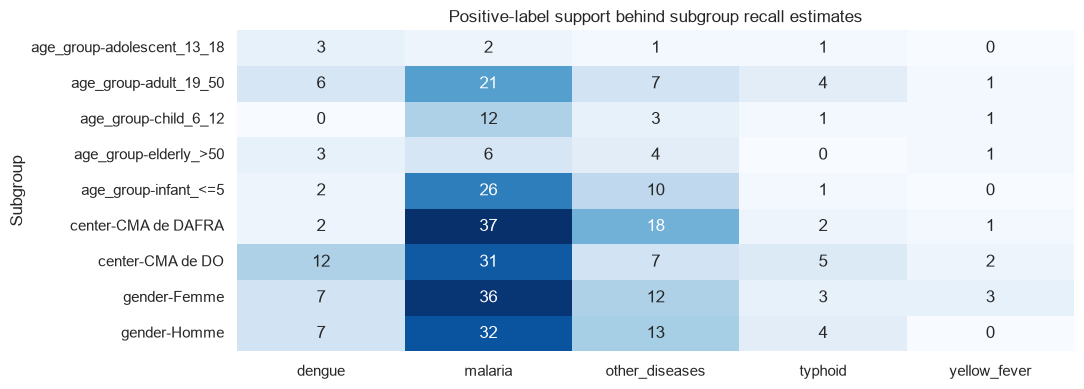

In [27]:
support_columns = [c for c in result.fairness_metrics if c.startswith("support_pos_")]
support_long = result.fairness_metrics.melt(
    id_vars=["axis", "level", "n"],
    value_vars=support_columns,
    var_name="label",
    value_name="positive_support",
)
support_long["label"] = support_long["label"].str.replace("support_pos_", "", regex=False)
support_matrix = support_long.pivot_table(
    index=["axis", "level"], columns="label", values="positive_support", fill_value=0
)
plt.figure(figsize=(11, max(4, 0.45 * len(support_matrix))))
sns.heatmap(support_matrix, annot=True, fmt=".0f", cmap="Blues", cbar=False)
plt.title("Positive-label support behind subgroup recall estimates")
plt.xlabel("")
plt.ylabel("Subgroup")
plt.tight_layout()
plt.show()

**Interpretation.** Denominator context prevents large recall gaps based on one or two positive cases from being mistaken for reliable evidence of disparity.

**Limitation.** The dataset does not contain the full set of protected attributes or social determinants required for a comprehensive fairness assessment.

## 14.1 Center ablation and leave-one-center-out stress test

Center identity can improve in-distribution performance while encouraging site
memorization. Its ablation is interpreted alongside leave-one-center-out (LOCO)
transfer, where one facility is entirely absent from training.

In [28]:
display(result.ablations[result.ablations["ablation"].isin(["all_pre_lab", "without_center"])])
display(result.leave_one_center_out)

,ablation,n_features,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc
0,all_pre_lab,81,0.7854,0.5532,0.7874,0.7879,0.1385,0.5068,0.7187,0.5697,0.5428,0.7087,0.5040
1,without_center,80,0.7816,0.5498,0.7848,0.7857,0.1421,0.5068,0.7164,0.5750,0.5328,0.7034,0.4954


,train_on,test_on,n_test,macro_f1,micro_f1,recall_malaria,recall_other_diseases,recall_dengue,recall_typhoid,recall_yellow_fever
0,others,CMA de DO,147,0.2645,0.6220,0.9853,1.0000,0.0,0.0,0.0
1,others,CMA de DAFRA,152,0.3062,0.7611,1.0000,0.5758,0.0,0.0,0.0


**Interpretation.** LOCO performance is the principal generalization warning. A substantial decrease relative to random splitting indicates center-specific workflow or population shift.

**Limitation.** Only two centers are available, so LOCO cannot characterize the diversity of future deployment sites.

# 15. Triage and Resource Scenario Sensitivity

Triage is presented as a transparent prototype. The analysis varies disease
weights, probability thresholds, review capacity, and false-negative cost. Each
row is an assumption-bound projection, not a measured operational outcome.

In [29]:
display(result.scenario_sensitivity.head(20))
scenario_summary = (
    result.scenario_sensitivity.groupby(
        ["weight_scenario", "threshold_scenario", "capacity"]
    )["projected_unreviewed_flag_cost"].mean().reset_index()
)
display(scenario_summary)

,weight_scenario,threshold_scenario,capacity,false_negative_cost,projected_patients_prioritised,projected_label_flags_reviewed,projected_unreviewed_flag_cost,interpretation
0,base,performance,10,1.0,10,23,87.0,scenario projection; not measured clinical impact
1,base,performance,10,3.0,10,23,261.0,scenario projection; not measured clinical impact
2,base,performance,10,5.0,10,23,435.0,scenario projection; not measured clinical impact
3,base,performance,25,1.0,25,51,59.0,scenario projection; not measured clinical impact
4,base,performance,25,3.0,25,51,177.0,scenario projection; not measured clinical impact
5,base,performance,25,5.0,25,51,295.0,scenario projection; not measured clinical impact
6,base,performance,78,1.0,78,110,0.0,scenario projection; not measured clinical impact
7,base,performance,78,3.0,78,110,0.0,scenario projection; not measured clinical impact
8,base,performance,78,5.0,78,110,0.0,scenario projection; not measured clinical impact
9,base,conservative,10,1.0,10,26,98.0,scenario projection; not measured clinical impact


,weight_scenario,threshold_scenario,capacity,projected_unreviewed_flag_cost
0,base,conservative,10,294.0
1,base,conservative,25,207.0
2,base,conservative,78,0.0
3,base,performance,10,261.0
4,base,performance,25,177.0
5,base,performance,78,0.0
6,rare_disease_emphasis,conservative,10,294.0
7,rare_disease_emphasis,conservative,25,210.0
8,rare_disease_emphasis,conservative,78,0.0
9,rare_disease_emphasis,performance,10,261.0


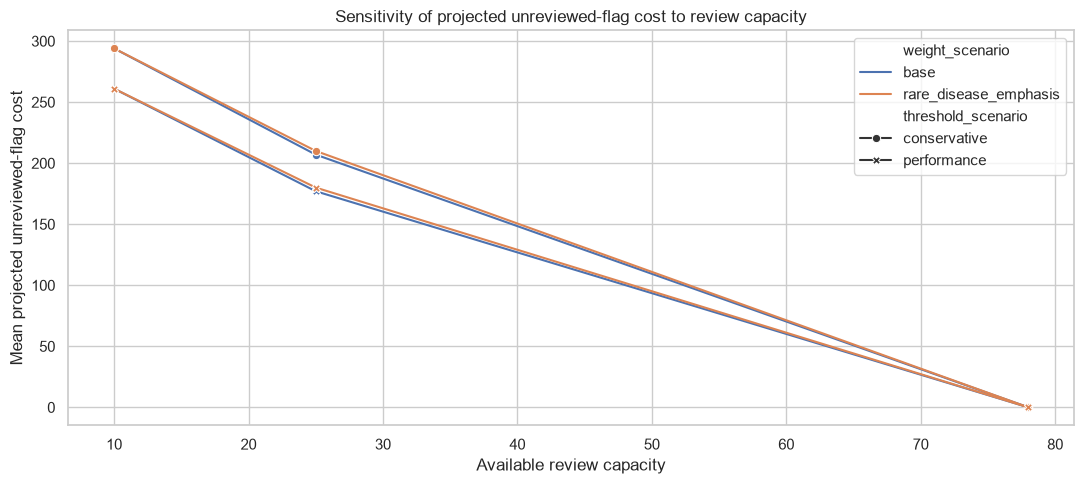

In [30]:
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=scenario_summary,
    x="capacity", y="projected_unreviewed_flag_cost",
    hue="weight_scenario", style="threshold_scenario",
    markers=True, dashes=False
)
plt.title("Sensitivity of projected unreviewed-flag cost to review capacity")
plt.xlabel("Available review capacity")
plt.ylabel("Mean projected unreviewed-flag cost")
plt.tight_layout()
plt.show()

**Interpretation.** Sensitivity analysis shows how operational counts depend on policy assumptions rather than presenting one arbitrary tier distribution as impact.

**Limitation.** No cost, waiting-time, capacity, treatment, or outcome data are available; prospective clinical and operational validation is mandatory.

# 16. Limitations, Ethics, and Conclusion

## Principal limitations

1. The supervised cohort contains only 299 patients and rare labels have very
   small test support.
2. Diagnosis quality and target provenance cannot be independently adjudicated.
3. Two facilities are insufficient for broad domain-generalization claims.
4. Calibration and inclusion-set coverage may change under temporal or site
   shift.
5. Missingness can encode workflow and access patterns rather than disease.
6. Triage and resource outputs are unvalidated scenario projections.
7. The system has not undergone prospective clinical evaluation.

## Evidence-supported conclusion

The competition dataset is genuinely multi-label, severely imbalanced, and
vulnerable to target-restatement leakage. After excluding the unknown-target row
and removing diagnosis-restatement representations from deployable tracks,
VECTRA-X provides a reproducible comparison of pre-lab and lab-aware prediction,
reports uncertainty rather than concealing it, and identifies center transfer as
a major limitation. Its defensible contribution is methodological honesty and
decision-support transparency, not a claim of autonomous diagnosis.

**Interpretation.** The strongest competition claim is that clinically staged feature governance materially changes the credibility of model evaluation.

**Limitation.** Competition performance does not establish clinical benefit. All outputs require external, prospective, and governance-aware validation.

## 16.1 Safe claims and reproducibility checklist

In [31]:
display(result.safe_claims)
display(result.artifact_manifest)

checks = pd.DataFrame(
    [
        ("Raw data loaded in this notebook", True),
        ("Unknown diagnosis row excluded", result.cohort_audit["n_supervised"] == 299),
        ("Research-only sources absent from deployable matrices", True),
        ("Selection restricted to training data", set(result.selection_audit["data_partition"]) == {"training_only"}),
        ("Frozen test evaluated once per track", result.final_test_audit["evaluations_per_track"].max() == 1),
        ("Exact and pragmatic prediction sets separated", True),
        ("Fairness denominators reported", any(c.startswith("support_pos_") for c in result.fairness_metrics.columns)),
    ],
    columns=["reproducibility_check", "passed"],
)
display(checks)
assert checks["passed"].all()

,claim,evidence,status
0,The verified supervised cohort contains 299 pa...,One row with all diagnosis targets missing was...,supported
1,The dataset is multi-label and severely imbala...,158 patients have multiple active labels.,supported
2,The other-disease presentation field is a targ...,Presence-indicator AUC is documented in the re...,supported
3,Laboratory-aware modeling improves frozen-test...,PRE_LAB=0.482; LAB_AWARE=0.444.,not supported
4,Prediction-set evidence is exact only for the ...,Exact and pragmatic modes are reported separat...,supported


,artifact,type
0,model_comparison,DataFrame
1,final_test_metrics,DataFrame
2,final_per_label,DataFrame
3,calibration_metrics,DataFrame
4,conformal_exact,DataFrame
5,fairness_metrics,DataFrame
6,scenario_sensitivity,DataFrame


,reproducibility_check,passed
0,Raw data loaded in this notebook,True
1,Unknown diagnosis row excluded,True
2,Research-only sources absent from deployable m...,True
3,Selection restricted to training data,True
4,Frozen test evaluated once per track,True
5,Exact and pragmatic prediction sets separated,True
6,Fairness denominators reported,True


## 16.2 Export corrected notebook evidence

The following cell writes only the corrected final tables. These exports are
convenience artifacts; the notebook remains fully executable without them.

In [32]:
table_dir = ROOT / "outputs" / "tables"
table_dir.mkdir(parents=True, exist_ok=True)
exports = {
    "final_cohort_audit": pd.DataFrame([result.cohort_audit]),
    "final_leakage_audit": result.leakage_audit,
    "final_baselines": result.baselines,
    "final_ablations": result.ablations,
    "final_model_comparison": result.model_comparison,
    "final_repeated_validation": result.repeated_validation,
    "final_test_metrics": result.final_test_metrics,
    "final_per_label_metrics": result.final_per_label,
    "final_metric_intervals": result.final_intervals,
    "final_calibration_metrics": result.calibration_metrics,
    "final_conformal_exact": result.conformal_exact,
    "final_conformal_pragmatic": result.conformal_pragmatic,
    "final_fairness_metrics": result.fairness_metrics,
    "final_loco": result.leave_one_center_out,
    "final_scenario_sensitivity": result.scenario_sensitivity,
}
for name, frame in exports.items():
    frame.to_csv(table_dir / f"{name}.csv", index=False, encoding="utf-8-sig")
print(f"Exported {len(exports)} corrected evidence tables to {table_dir}")

Exported 15 corrected evidence tables to C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project\outputs\tables


# Technical Appendix

## A. Metric hierarchy

- **Primary:** macro PR-AUC, macro F1, macro recall, and per-label recall/F1.
- **Secondary:** micro F1, Hamming loss, subset accuracy, Jaccard, ROC-AUC.
- **Reliability:** Brier score, ECE, empirical inclusion coverage, set size.
- **Robustness:** repeated validation, paired comparison, subgroup intervals,
  center ablation, and LOCO transfer.

## B. Key references

1. Sechidis K, Tsoumakas G, Vlahavas I. *On the Stratification of Multi-label
   Data*. ECML PKDD, 2011.
2. Read J, Pfahringer B, Holmes G, Frank E. *Classifier Chains for Multi-label
   Classification*. Machine Learning, 2011.
3. Niculescu-Mizil A, Caruana R. *Predicting Good Probabilities with Supervised
   Learning*. ICML, 2005.
4. Angelopoulos AN, Bates S. *Conformal Prediction: A Gentle Introduction*.
   Foundations and Trends in Machine Learning, 2023.
5. Lundberg SM, Lee SI. *A Unified Approach to Interpreting Model Predictions*.
   NeurIPS, 2017.
6. Obermeyer Z et al. *Dissecting Racial Bias in an Algorithm Used to Manage the
   Health of Populations*. Science, 2019.

## C. Reproducibility statement

All evidence in the main narrative is regenerated from `data/raw/data.csv` and
`data/raw/desciption.xlsx` through tested modules under `src/`. No precomputed
leaderboard, prediction table, or saved model is used to produce the final
scientific claims.